   longitude  latitude  housing_median_age  total_rooms  total_bedrooms  \
0    -122.24     37.85                52.0       1467.0           190.0   
1    -122.25     37.85                52.0       1274.0           235.0   
2    -122.25     37.85                52.0       1627.0           280.0   
3    -122.25     37.85                52.0        919.0           213.0   
4    -122.25     37.84                52.0       2535.0           489.0   

   population  households  median_income  median_house_value ocean_proximity  \
0       496.0       177.0         7.2574            352100.0        NEAR BAY   
1       558.0       219.0         5.6431            341300.0        NEAR BAY   
2       565.0       259.0         3.8462            342200.0        NEAR BAY   
3       413.0       193.0         4.0368            269700.0        NEAR BAY   
4      1094.0       514.0         3.6591            299200.0        NEAR BAY   

   rooms_per_household  bedrooms_per_room  population_per_household 

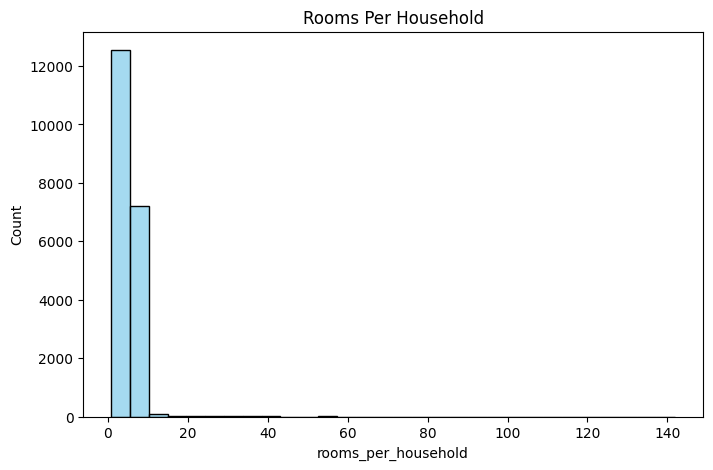

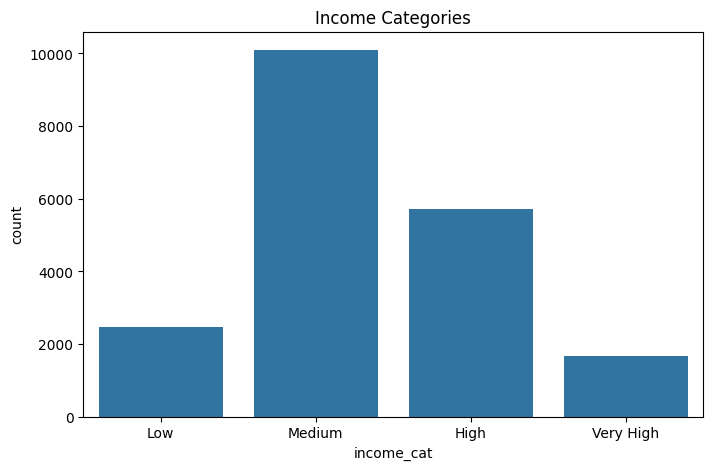

Feature engineering completed successfully.


In [1]:
#import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load cleaned dataset
df = pd.read_csv("../data/cleaned_housing.csv")

# Create new features

# Rooms per household
df['rooms_per_household'] = (
    df['total_rooms'] / df['households']
)

# Bedrooms per room
df['bedrooms_per_room'] = (
    df['total_bedrooms'] / df['total_rooms']
)

# Population per household
df['population_per_household'] = (
    df['population'] / df['households']
)

# Income category
df['income_cat'] = pd.cut(
    df['median_income'],
    bins=[0, 2, 4, 6, np.inf],
    labels=['Low', 'Medium', 'High', 'Very High']
)

# Display updated dataset
print(df.head())

# Visualizations

# Histogram
plt.figure(figsize=(8,5))
sns.histplot(df['rooms_per_household'], bins=30, color='skyblue')
plt.title("Rooms Per Household")
plt.show()

# Countplot
plt.figure(figsize=(8,5))
sns.countplot(x=df['income_cat'])
plt.title("Income Categories")
plt.show()

# Save feature engineered dataset
df.to_csv("../data/feature_engineered_housing.csv", index=False)

print("Feature engineering completed successfully.")